# Options Quant — Sleeve Allocation Framework (α Engine, **local POC**)

Local twin of `sleeve_alpha.ipynb`. All-official free data: CBOE (SPX/VIX/VIX3M/SKEW/VXN) + FRED (NASDAQ100/DGS3MO). Produces the same identifier set so Section 2+ math copies back to the Cron2 notebook verbatim.

Universe: SPX (S&P 500 index) and NDX (NASDAQ-100 index). Full signal stack on both — iv30_90mny and NDX iv90_atm are synthesized from VIX/VXN/SKEW (POC; absolute level uncalibrated, monotonic enough for percentile-rank signals).


## Section 0 — Setup & Config


In [1]:
import pathlib
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt

from local_data import con  # FreeCon — drop-in for Cron2 emds_client.con


In [2]:
UNDERLYINGS = {
    "SPX": "SPX Index",
    "NDX": "NDX Index",
}
REQUIRED_UNDERLYINGS = ("SPX", "NDX")

IV_FIELDS = {
    "iv30_atm":   "30DAY_IMPVOL_100.0%MNY_DF",
    "iv30_90mny": "30DAY_IMPVOL_90.0%MNY_DF",
    "iv90_atm":   "90DAY_IMPVOL_100.0%MNY_DF",
}
PRICE_FIELD = "PX_LAST"

CROSS_ASSET = {
    "vix":     ("VIX Index",     "PX_LAST"),
    "rf_rate": ("USGG3M Index",  "PX_LAST"),
}

START_DATE = "2010-01-01"
END_DATE   = dt.date.today().isoformat()


In [3]:
def nyse_index(start, end):
    sched = mcal.get_calendar("NYSE").schedule(start_date=start, end_date=end)
    return pd.DatetimeIndex(sched.index).normalize()

NYSE_INDEX = nyse_index(START_DATE, END_DATE)
print(f"NYSE_INDEX: n={len(NYSE_INDEX)}, {NYSE_INDEX.min().date()} → {NYSE_INDEX.max().date()}")


NYSE_INDEX: n=4108, 2010-01-04 → 2026-05-04


## Section 1 — Data Layer

### 1.1 Raw pulls (per-underlying, per-field)


In [4]:
raw_pulls = {u: {} for u in UNDERLYINGS}
for u, ticker in UNDERLYINGS.items():
    raw_pulls[u]["price"] = con.bdh(ticker, PRICE_FIELD, START_DATE, END_DATE)
    for fkey, fname in IV_FIELDS.items():
        raw_pulls[u][fkey] = con.bdh(ticker, fname, START_DATE, END_DATE)

pull_log = []
for u in UNDERLYINGS:
    for fkey, df in raw_pulls[u].items():
        pull_log.append({
            "underlying": u, "field": fkey,
            "n": len(df),
            "status": "landed" if len(df) else "deferred",
        })
pd.DataFrame(pull_log).pivot(index="underlying", columns="field", values="n").fillna(0).astype(int)


field,iv30_90mny,iv30_atm,iv90_atm,price
underlying,,,,
NDX,4102,4109,4107,4108
SPX,4102,4136,4107,4107


### 1.2 Cross-asset pulls


In [5]:
raw_cross = {}
for name, (ticker, field) in CROSS_ASSET.items():
    raw_cross[name] = con.bdh(ticker, field, START_DATE, END_DATE)

pd.DataFrame({
    "ticker": [CROSS_ASSET[k][0] for k in raw_cross],
    "n":      [len(raw_cross[k]) for k in raw_cross],
    "status": ["landed" if len(raw_cross[k]) else "deferred" for k in raw_cross],
}, index=list(raw_cross))


,ticker,n,status
vix,VIX Index,4136,landed
rf_rate,USGG3M Index,4084,landed


### 1.3 Panel assembly

Wide panels on `NYSE_INDEX`. Naming: `iv90mny` is the 90%-moneyness 30D IV (skew leg). `iv90_panel` is the 90D ATM IV probe. `skew_panel = iv90mny - iv_panel`. Truncated to the shortest IV history per D-04.


In [6]:
def _to_series(df, name):
    if df is None or len(df) == 0:
        return None
    s = df.squeeze()
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s.index = pd.DatetimeIndex(s.index).normalize()
    s.name = name
    return s

def _build_panel(field_key, underlyings_with_data):
    cols = {}
    for u in underlyings_with_data:
        s = _to_series(raw_pulls[u][field_key], u)
        if s is not None:
            cols[u] = s.reindex(NYSE_INDEX)
    return pd.DataFrame(cols, index=NYSE_INDEX)

landed = [
    u for u in UNDERLYINGS
    if len(raw_pulls[u].get("price", pd.DataFrame())) > 0
    and len(raw_pulls[u].get("iv30_atm", pd.DataFrame())) > 0
    and len(raw_pulls[u].get("iv30_90mny", pd.DataFrame())) > 0
]
print(f"Landed underlyings: {landed}")

prices_panel_full = _build_panel("price",      list(UNDERLYINGS))
iv_panel_full     = _build_panel("iv30_atm",   landed)
iv90mny_full      = _build_panel("iv30_90mny", landed)
iv90_panel_full   = _build_panel(
    "iv90_atm",
    [u for u in landed if len(raw_pulls[u].get("iv90_atm", pd.DataFrame())) > 0],
)

iv_first_dates = []
for u in landed:
    s = iv_panel_full[u].dropna()
    if len(s):
        iv_first_dates.append(s.index.min())
truncate_start = max(iv_first_dates) if iv_first_dates else NYSE_INDEX.min()
print(f"Truncating to start={truncate_start.date()} (shortest IV history)")

mask = NYSE_INDEX >= truncate_start
prices_panel = prices_panel_full.loc[mask].copy()
iv_panel     = iv_panel_full.loc[mask].copy()
iv90mny      = iv90mny_full.loc[mask].copy()
iv90_panel   = iv90_panel_full.loc[mask].copy()

common_skew_cols = [c for c in iv_panel.columns if c in iv90mny.columns]
skew_panel = iv90mny[common_skew_cols] - iv_panel[common_skew_cols]

pd.DataFrame({
    "prices_panel": prices_panel.notna().sum(),
    "iv_panel":     iv_panel.reindex(columns=prices_panel.columns).notna().sum(),
    "iv90_panel":   iv90_panel.reindex(columns=prices_panel.columns).notna().sum(),
    "skew_panel":   skew_panel.reindex(columns=prices_panel.columns).notna().sum(),
}).T


Landed underlyings: ['SPX', 'NDX']
Truncating to start=2010-01-04 (shortest IV history)


,SPX,NDX
prices_panel,4107,4107
iv_panel,4107,4107
iv90_panel,4107,4107
skew_panel,4102,4102


### 1.4 Cross-asset Series


In [7]:
def _to_named_series(name):
    df = raw_cross.get(name, pd.DataFrame())
    if df is None or len(df) == 0:
        s = pd.Series(index=NYSE_INDEX, dtype="float64", name=name)
    else:
        s = df.squeeze()
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        s.index = pd.DatetimeIndex(s.index).normalize()
        s.name = name
        s = s.reindex(NYSE_INDEX)
    return s.loc[NYSE_INDEX >= truncate_start]

vix     = _to_named_series("vix")
rf_rate = _to_named_series("rf_rate")

for s in (vix, rf_rate):
    assert isinstance(s, pd.Series), f"{s.name} must be a Series, got {type(s)}"
    assert s.index.equals(prices_panel.index), f"{s.name} index mismatch"

pd.DataFrame({
    "n_obs":   [s.notna().sum() for s in (vix, rf_rate)],
    "first":   [s.dropna().index.min() if s.notna().any() else None for s in (vix, rf_rate)],
    "last":    [s.dropna().index.max() if s.notna().any() else None for s in (vix, rf_rate)],
    "latest":  [s.dropna().iloc[-1] if s.notna().any() else None for s in (vix, rf_rate)],
}, index=["vix","rf_rate"])


,n_obs,first,last,latest
vix,4107,2010-01-04,2026-05-01,16.99
rf_rate,4076,2010-01-04,2026-04-30,3.68


### 1.5 Quick visual sanity check


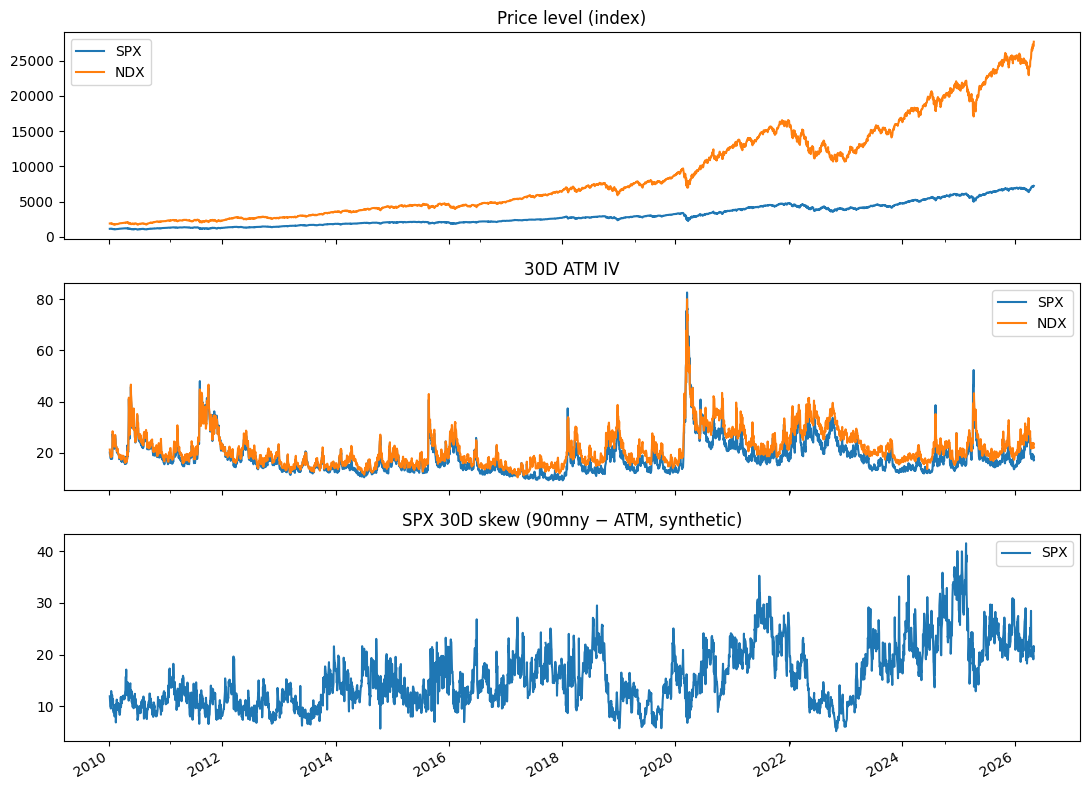

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
prices_panel[[c for c in ("SPX","NDX") if c in prices_panel.columns]].plot(ax=axes[0], title="Price level (index)")
iv_panel[[c for c in ("SPX","NDX") if c in iv_panel.columns]].plot(ax=axes[1], title="30D ATM IV")
if "SPX" in skew_panel.columns:
    skew_panel[["SPX"]].plot(ax=axes[2], title="SPX 30D skew (90mny − ATM, synthetic)")
plt.tight_layout()
plt.show()


## Section 2 — Signal Engineering

Six raw signals per underlying, then causal percentile-rank (5y rolling window) so values are comparable across underlyings and regimes. No full-sample lookahead — at each date *t* the rank uses only data from *t-5y* to *t*.

| Signal | Raw definition | Direction* |
|---|---|---|
| `rv30` | 30D rolling stdev of log returns × √252 | — |
| `vrp` | iv30_atm − rv30 | high → vol-sellers paid more |
| `term` | iv90_atm − iv30_atm | high → contango (vol-sellers favoured) |
| `skew` | iv30_90mny − iv30_atm | high → expensive tails |
| `trend` | log(spot / SMA200) | high → uptrend |
| `dd` | spot / rolling-max(252) − 1 | low (negative) → drawdown |

*Direction interpretation lives in Section 4 (scorecard); Section 2 just produces the signals.*


### 2.1 Returns & realized vol


In [9]:
log_ret = np.log(prices_panel / prices_panel.shift(1))
rv30 = log_ret.rolling(window=21, min_periods=15).std() * np.sqrt(252) * 100  # vol pts
rv30.tail(3)


,SPX,NDX
2026-04-30,11.633142,15.101223
2026-05-01,11.614280,15.028803
2026-05-04,11.848241,15.269557


### 2.2 Raw signal panels


In [10]:
vrp   = iv_panel - rv30
term  = iv90_panel - iv_panel
skew  = skew_panel.copy()  # already iv30_90mny - iv30_atm from Section 1
trend = np.log(prices_panel / prices_panel.rolling(200, min_periods=100).mean())
dd    = prices_panel / prices_panel.rolling(252, min_periods=100).max() - 1.0

raw_signals = {
    "rv30":  rv30,
    "vrp":   vrp,
    "term":  term,
    "skew":  skew,
    "trend": trend,
    "dd":    dd,
}
pd.DataFrame({k: v.notna().sum() for k, v in raw_signals.items()}).T.rename(columns=lambda c: c).head()


,SPX,NDX
rv30,4093,4093
vrp,4092,4092
term,4107,4107
skew,4102,4102
trend,4008,4008


### 2.3 Causal percentile rank (5y rolling)

Each signal is ranked within its own 5y rolling window, per underlying. Output ∈ [0, 1] where 0.5 is the trailing-5y median. Window length is a deliberate balance — long enough to span GFC/COVID-class episodes (~1y), short enough to adapt to regime change.


In [11]:
PCT_WINDOW   = 1260  # ~5y of trading days
PCT_MIN_OBS  = 252   # 1y warm-up

def causal_pct_rank(panel: pd.DataFrame) -> pd.DataFrame:
    return panel.rolling(window=PCT_WINDOW, min_periods=PCT_MIN_OBS).rank(pct=True)

pct_signals = {k: causal_pct_rank(v) for k, v in raw_signals.items()}

pd.DataFrame({k: v.notna().sum() for k, v in pct_signals.items()}).T.rename(
    columns=lambda c: c
)


,SPX,NDX
rv30,3842,3842
vrp,3841,3841
term,3856,3856
skew,3851,3851
trend,3757,3757
dd,3757,3757


### 2.4 Fragility composite

Single "how stressed is this market" score blending vol-pricing dimensions. POC weights — Phase 4 will rationalize / tune.

`fragility = mean(vrp_pct, skew_pct, -trend_pct, -dd_pct)` — high when vol expensive, skew steep, trend weak, drawdown deep. Range ∈ [0, 1] (each component is a percentile rank, negation flips so all components point the same way).


In [12]:
def _flip(p): return 1.0 - p

fragility = (
    pct_signals["vrp"]
    + pct_signals["skew"]
    + _flip(pct_signals["trend"])
    + _flip(pct_signals["dd"])
) / 4.0

pct_signals["fragility"] = fragility
fragility.tail(3)


,SPX,NDX
2026-04-30,0.434536,0.437711
2026-05-01,0.415773,0.407340
2026-05-04,NaN,NaN


### 2.5 Latest signal snapshot


In [13]:
latest = pd.DataFrame({
    sig: panel.iloc[-1] for sig, panel in pct_signals.items()
}).T
latest.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=1).format("{:.2f}") if hasattr(latest, "style") else latest


,SPX,NDX
rv30,0.38,0.28
vrp,nan,nan
term,nan,nan
skew,nan,nan
trend,nan,nan
dd,nan,nan
fragility,nan,nan


### 2.6 Signal time-series


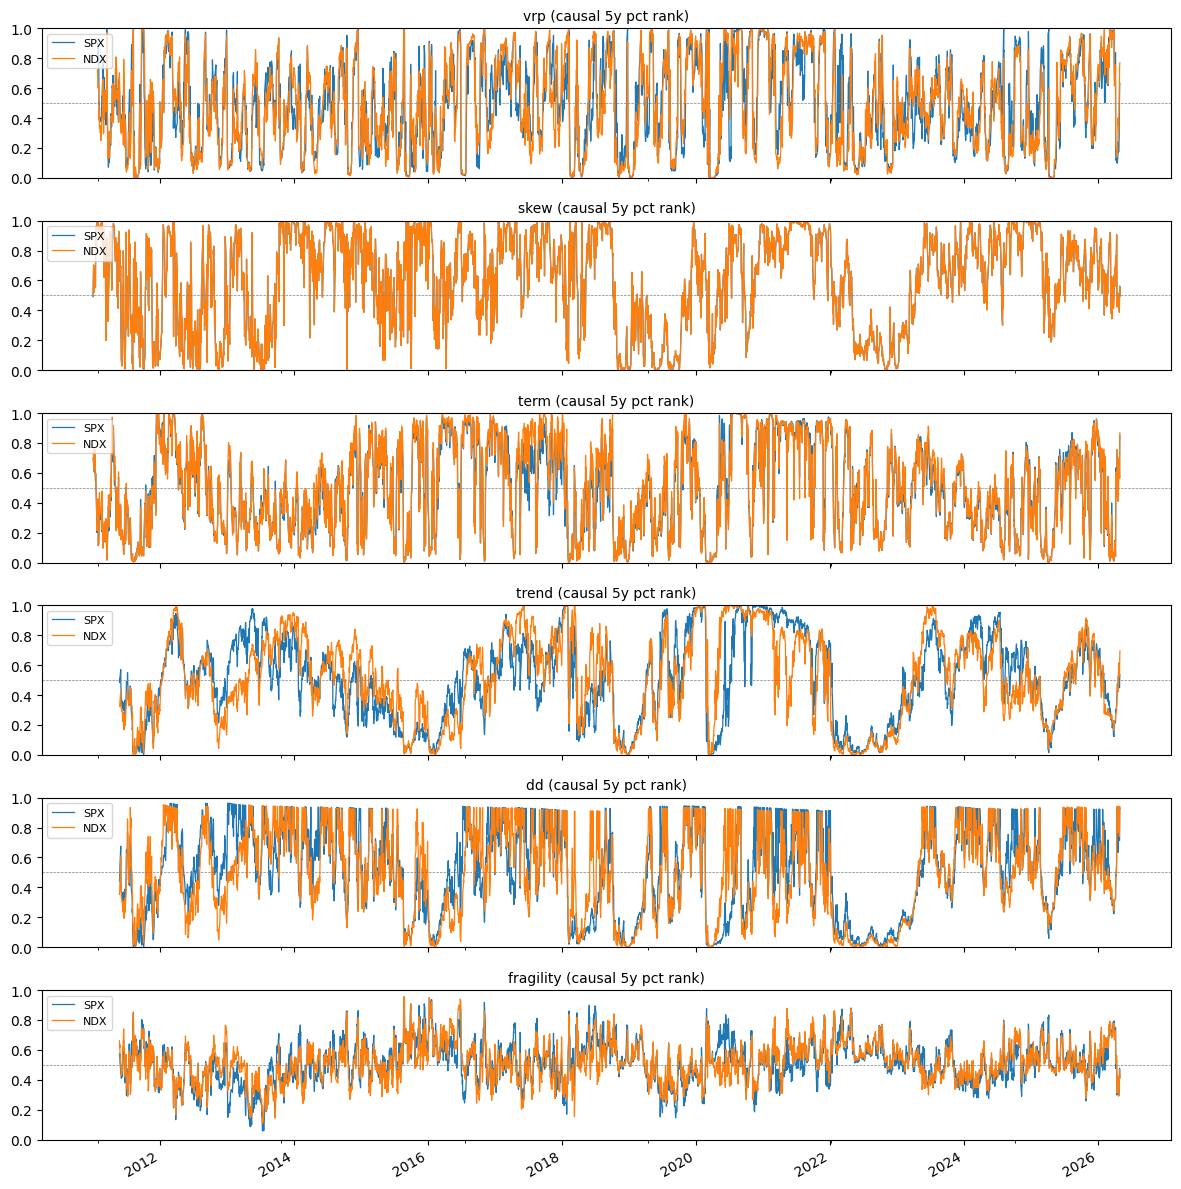

In [14]:
sigs_to_plot = ["vrp", "skew", "term", "trend", "dd", "fragility"]
fig, axes = plt.subplots(len(sigs_to_plot), 1, figsize=(12, 2*len(sigs_to_plot)), sharex=True)
for ax, sig in zip(axes, sigs_to_plot):
    pct_signals[sig].plot(ax=ax, lw=0.9)
    ax.axhline(0.5, color="grey", ls="--", lw=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(f"{sig} (causal 5y pct rank)", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## Section 3 — Sleeve Backtest Engine

Black-Scholes-priced monthly-roll backtests for four sleeves on each underlying. Output: per-roll P&L panels and cumulative equity curves, plus summary stats.

**Sleeves (per PROJECT.md):**

| Sleeve | Position |
|---|---|
| `cc` (Covered Call)         | long underlying + short OTM call (~0.25Δ)         |
| `csp` (Cash-Covered Put)    | cash earning rf + short OTM put (~0.25Δ)          |
| `collar`                    | long underlying + short 0.25Δ call − long 0.25Δ put |
| `strangle` (Short Strangle) | cash + short 0.25Δ call + short 0.25Δ put         |

**POC simplifications (flag for Phase 6 refinement):**
- Flat ATM vol pricing — uses `iv_atm` for all strikes; skew differential not priced.
- 0% dividend yield (SPX/NDX index level; real div yields are ~1-2%).
- 0 transaction costs / bid-ask. Realistic SPX/NDX 30D options have ~5-10bp round-trip.
- Monthly roll on 3rd Friday (standard expiry).
- Strikes set at trade open from spot + ATM IV; held to expiry, settled vs. realized spot.


### 3.1 Black-Scholes utilities


In [15]:
from scipy.stats import norm

def bs_price(S, K, T, r, sigma, q=0.0, kind="call"):
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K) if kind == "call" else max(0.0, K - S)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if kind == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def bs_strike_from_delta(S, T, r, sigma, target_delta, q=0.0, kind="call"):
    """Strike K such that BS delta == target_delta. Closed-form."""
    if kind == "call":
        d1 = norm.ppf(target_delta * np.exp(q*T))
    else:
        d1 = -norm.ppf(-target_delta * np.exp(q*T))
    return S * np.exp(-(d1*sigma*np.sqrt(T)) + (r - q + 0.5*sigma**2)*T)

S_demo, T_demo, r_demo, sig_demo = 5800.0, 30/365, 0.04, 0.15
K_call = bs_strike_from_delta(S_demo, T_demo, r_demo, sig_demo, 0.25, kind="call")
K_put  = bs_strike_from_delta(S_demo, T_demo, r_demo, sig_demo, -0.25, kind="put")
P_call = bs_price(S_demo, K_call, T_demo, r_demo, sig_demo, kind="call")
P_put  = bs_price(S_demo, K_put,  T_demo, r_demo, sig_demo, kind="put")
print(f"Demo: SPX=5800, 30D, r=4%, sigma=15%")
print(f"  0.25Δ call: K={K_call:.0f}  premium={P_call:.2f}  ({P_call/S_demo*100:.2f}% of spot)")
print(f"  0.25Δ put:  K={K_put:.0f}  premium={P_put:.2f}  ({P_put/S_demo*100:.2f}% of spot)")


Demo: SPX=5800, 30D, r=4%, sigma=15%
  0.25Δ call: K=5996  premium=36.42  (0.63% of spot)
  0.25Δ put:  K=5658  premium=38.02  (0.66% of spot)


### 3.2 Roll-date generator

Standard equity option expiry: 3rd Friday of each month.


In [16]:
def third_fridays(start, end):
    out = []
    cur = pd.Timestamp(start).to_period("M").to_timestamp()
    while cur <= pd.Timestamp(end):
        first = cur.replace(day=1)
        offset = (4 - first.weekday()) % 7  # Friday=4
        third = first + pd.Timedelta(days=offset + 14)
        if pd.Timestamp(start) <= third <= pd.Timestamp(end):
            out.append(third.normalize())
        cur = (cur + pd.offsets.MonthBegin(1))
    return pd.DatetimeIndex(out)

roll_dates = third_fridays(prices_panel.index.min(), prices_panel.index.max())
roll_dates = pd.DatetimeIndex([d for d in roll_dates if d in prices_panel.index or prices_panel.index.searchsorted(d) < len(prices_panel)])
# snap to nearest prior trading day if 3rd Friday is a holiday
snapped = []
for d in roll_dates:
    if d in prices_panel.index:
        snapped.append(d)
    else:
        loc = prices_panel.index.searchsorted(d) - 1
        if loc >= 0:
            snapped.append(prices_panel.index[loc])
roll_dates = pd.DatetimeIndex(snapped).unique()
print(f"Roll dates: n={len(roll_dates)}, first={roll_dates[0].date()}, last={roll_dates[-1].date()}")


Roll dates: n=196, first=2010-01-15, last=2026-04-17


### 3.3 Per-roll P&L for each sleeve

At each roll date *t*: open positions sized to spot, hold to next roll date *t+1*, settle. Per-roll return is in fraction-of-spot units so P&L from CC vs Strangle is comparable.


In [17]:
DELTA_TARGET   = 0.25
STRANGLE_DELTA = 0.20

def _vol_decimal(iv_vol_pts):
    return iv_vol_pts / 100.0  # IV stored in vol pts (e.g. 15.0 → 0.15)

def _rate_decimal(rf_pct):
    return rf_pct / 100.0

def backtest_sleeves(underlying):
    S = prices_panel[underlying]
    iv = iv_panel[underlying]
    rolls = []
    for i, t0 in enumerate(roll_dates[:-1]):
        t1 = roll_dates[i+1]
        S0, S1 = S.loc[t0], S.loc[t1]
        sig = _vol_decimal(iv.loc[t0])
        r   = _rate_decimal(rf_rate.loc[t0]) if not pd.isna(rf_rate.loc[t0]) else 0.04
        if pd.isna(S0) or pd.isna(S1) or pd.isna(sig) or sig <= 0:
            continue
        T = max((t1 - t0).days / 365.0, 1/365)

        K_call_25 = bs_strike_from_delta(S0, T, r, sig, +DELTA_TARGET, kind="call")
        K_put_25  = bs_strike_from_delta(S0, T, r, sig, -DELTA_TARGET, kind="put")
        K_call_20 = bs_strike_from_delta(S0, T, r, sig, +STRANGLE_DELTA, kind="call")
        K_put_20  = bs_strike_from_delta(S0, T, r, sig, -STRANGLE_DELTA, kind="put")
        P_call_25 = bs_price(S0, K_call_25, T, r, sig, kind="call")
        P_put_25  = bs_price(S0, K_put_25,  T, r, sig, kind="put")
        P_call_20 = bs_price(S0, K_call_20, T, r, sig, kind="call")
        P_put_20  = bs_price(S0, K_put_20,  T, r, sig, kind="put")

        spot_ret = (S1 - S0) / S0
        rf_ret   = r * T
        cc_ret       = spot_ret + (P_call_25 - max(S1 - K_call_25, 0)) / S0
        csp_ret      = rf_ret   + (P_put_25  - max(K_put_25  - S1, 0)) / S0
        collar_ret   = spot_ret + (P_call_25 - max(S1 - K_call_25, 0)) / S0 \
                                + (-P_put_25 + max(K_put_25  - S1, 0)) / S0
        strangle_ret = rf_ret   + (P_call_20 - max(S1 - K_call_20, 0)) / S0 \
                                + (P_put_20  - max(K_put_20  - S1, 0)) / S0

        rolls.append({
            "open": t0, "close": t1, "S0": S0, "S1": S1,
            "sigma": sig, "rate": r, "T_days": (t1-t0).days,
            "spot_ret": spot_ret,
            "cc": cc_ret, "csp": csp_ret, "collar": collar_ret, "strangle": strangle_ret,
        })
    return pd.DataFrame(rolls).set_index("close")

rolls_spx = backtest_sleeves("SPX")
rolls_ndx = backtest_sleeves("NDX")
print(f"SPX rolls: {len(rolls_spx)}, span {rolls_spx.index.min().date()} → {rolls_spx.index.max().date()}")
print(f"NDX rolls: {len(rolls_ndx)}")
rolls_spx[["spot_ret","cc","csp","collar","strangle"]].tail(3)


SPX rolls: 195, span 2010-02-19 → 2026-04-17
NDX rolls: 195


,spot_ret,cc,csp,collar,strangle
close,,,,,
2026-02-20,-0.004395,0.002754,0.011029,-0.004755,0.014490
2026-03-20,-0.058330,-0.050648,-0.016454,-0.031363,-0.004216
2026-04-17,0.095225,0.067891,0.014357,0.056403,-0.005363


### 3.4 Equity curves & summary stats


In [18]:
sleeves = ["spot_ret", "cc", "csp", "collar", "strangle"]

def equity_and_stats(rolls):
    eq = (1 + rolls[sleeves]).cumprod()
    rets = rolls[sleeves]
    n_per_year = 12  # monthly rolls
    stats = pd.DataFrame({
        "cagr":  (eq.iloc[-1] ** (n_per_year / len(rets)) - 1),
        "vol":   rets.std() * np.sqrt(n_per_year),
        "sharpe": rets.mean() / rets.std() * np.sqrt(n_per_year),
        "max_dd": (eq / eq.cummax() - 1).min(),
        "hit":   (rets > 0).mean(),
    })
    return eq, stats

eq_spx, stats_spx = equity_and_stats(rolls_spx)
eq_ndx, stats_ndx = equity_and_stats(rolls_ndx)
print("SPX sleeve stats:")
print(stats_spx.round(3))
print("\nNDX sleeve stats:")
print(stats_ndx.round(3))


SPX sleeve stats:
           cagr    vol  sharpe  max_dd    hit
spot_ret  0.120  0.171   0.754  -0.309  0.682
cc        0.173  0.154   1.127  -0.303  0.749
csp       0.041  0.085   0.520  -0.272  0.887
collar    0.148  0.099   1.456  -0.149  0.682
strangle  0.073  0.082   0.910  -0.276  0.836

NDX sleeve stats:
           cagr    vol  sharpe  max_dd    hit
spot_ret  0.178  0.199   0.930  -0.322  0.713
cc        0.205  0.168   1.202  -0.257  0.728
csp       0.049  0.078   0.651  -0.211  0.882
collar    0.172  0.117   1.418  -0.216  0.713
strangle  0.065  0.077   0.858  -0.232  0.805


### 3.5 Equity-curve comparison


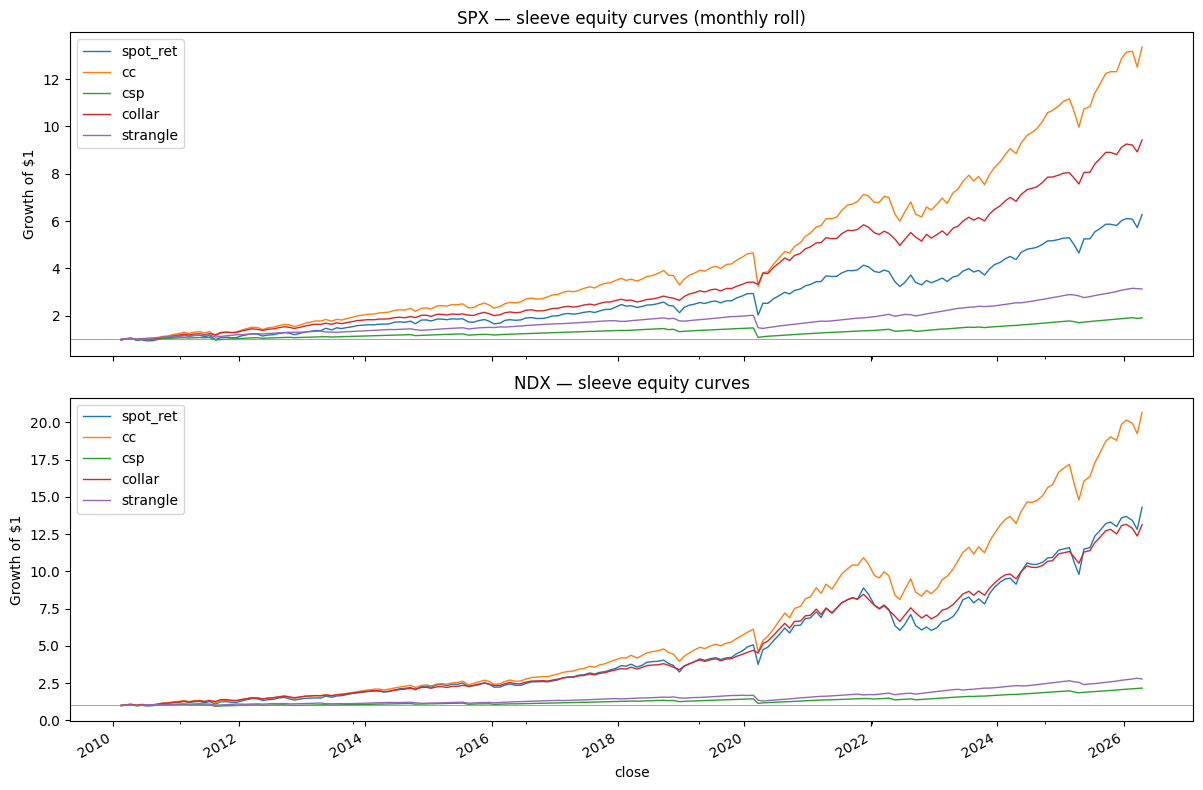

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
eq_spx.plot(ax=axes[0], lw=1.0); axes[0].set_title("SPX — sleeve equity curves (monthly roll)")
axes[0].set_ylabel("Growth of $1"); axes[0].axhline(1, color="grey", lw=0.5)
eq_ndx.plot(ax=axes[1], lw=1.0); axes[1].set_title("NDX — sleeve equity curves")
axes[1].set_ylabel("Growth of $1"); axes[1].axhline(1, color="grey", lw=0.5)
plt.tight_layout(); plt.show()
